<a href="https://colab.research.google.com/github/sunilmange/DeepLearning_per_ANN_CNN/blob/main/Deeplearning_per_ANN_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models


In [68]:
df = pd.read_csv("mnist_train.csv")
df_test = pd.read_csv("mnist_test.csv")

In [6]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df.shape

(20642, 785)

In [9]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20642 entries, 0 to 20641
Columns: 785 entries, label to 28x28
dtypes: float64(203), int64(582)
memory usage: 123.6 MB


In [14]:
df.isnull().sum()

,0
label,0
1x1,0
1x2,0
1x3,0
1x4,0
...,...
28x24,1
28x25,1
28x26,1
28x27,1


In [25]:
X_train = df.drop("label", axis=1).values
y_train = df["label"].values
X_test = df_test.drop("label", axis=1).values
y_test = df_test["label"].values

# Fill NaN values with 0 before type conversion and scaling
X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


X_train_img = X_train.reshape(-1, 28, 28) # -1 is the first row and 28*28 martix,pixels
X_test_img = X_test.reshape(-1, 28, 28)


y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

In [34]:
from tensorflow.keras.optimizers import SGD
perceptron.compile(optimizer=SGD(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

In [35]:
history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)


Epoch 1/5
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3187 - loss: 2.0618 - val_accuracy: 0.5433 - val_loss: 1.7838
Epoch 2/5
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6295 - loss: 1.6116 - val_accuracy: 0.7102 - val_loss: 1.4365
Epoch 3/5
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7301 - loss: 1.3356 - val_accuracy: 0.7696 - val_loss: 1.2155
Epoch 4/5
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7727 - loss: 1.1556 - val_accuracy: 0.7961 - val_loss: 1.0670
Epoch 5/5
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7949 - loss: 1.0316 - val_accuracy: 0.8124 - val_loss: 0.9620


In [36]:
acc_percp = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]



In [28]:
acc_percp

0.09799999743700027

In [37]:
y_pred_percp = perceptron.predict(X_test_img)
y_pred_classes_percp = np.argmax(y_pred_percp, axis=1)

manual_acc_percp = accuracy_score(y_test, y_pred_classes_percp)
print(f"Manual Perceptron Test Accuracy: {manual_acc_percp:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Manual Perceptron Test Accuracy: 0.8124


In [39]:

#ANN
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [40]:
from tensorflow.keras.optimizers import Adam
ann.compile(optimizer=Adam(learning_rate=0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

In [41]:
history_ann = ann.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)


Epoch 1/5
646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7570 - loss: 0.9916 - val_accuracy: 0.8957 - val_loss: 0.4182
Epoch 2/5
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9034 - loss: 0.3615 - val_accuracy: 0.9174 - val_loss: 0.3085
Epoch 3/5
646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9209 - loss: 0.2858 - val_accuracy: 0.9265 - val_loss: 0.2644
Epoch 4/5
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9325 - loss: 0.2444 - val_accuracy: 0.9315 - val_loss: 0.2423
Epoch 5/5
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9399 - loss: 0.2165 - val_accuracy: 0.9362 - val_loss: 0.2239


In [42]:

acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [43]:


acc_ann

0.9362000226974487

In [44]:

X_train_cnn = X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [45]:

cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [46]:

cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [47]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)


Epoch 1/5
646/646 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8792 - loss: 0.3943 - val_accuracy: 0.9737 - val_loss: 0.0859
Epoch 2/5
646/646 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.9612 - loss: 0.1333 - val_accuracy: 0.9823 - val_loss: 0.0567
Epoch 3/5
646/646 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9700 - loss: 0.0965 - val_accuracy: 0.9840 - val_loss: 0.0487
Epoch 4/5
646/646 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9773 - loss: 0.0781 - val_accuracy: 0.9858 - val_loss: 0.0469
Epoch 5/5
646/646 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.9815 - loss: 0.0636 - val_accuracy: 0.9855 - val_loss: 0.0432


In [48]:


acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]


In [49]:

acc_cnn

0.9854999780654907

In [50]:

def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

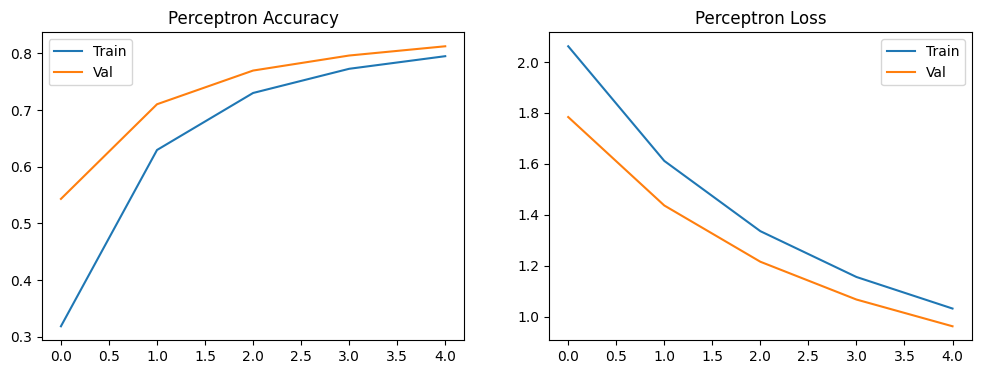

In [51]:

plot_training(history_percp, "Perceptron")

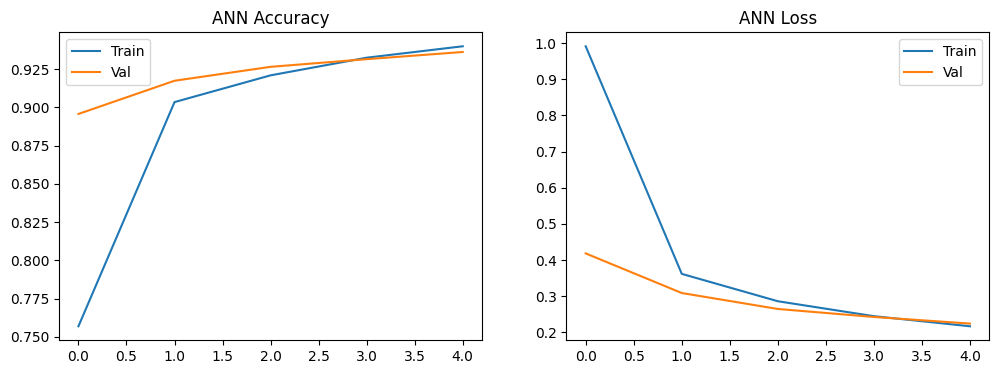

In [52]:


plot_training(history_ann, "ANN")

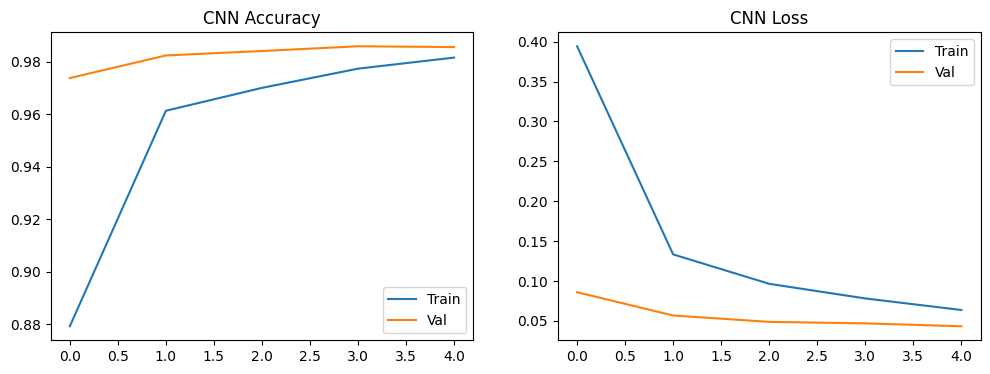

In [53]:

plot_training(history_cnn, "CNN")

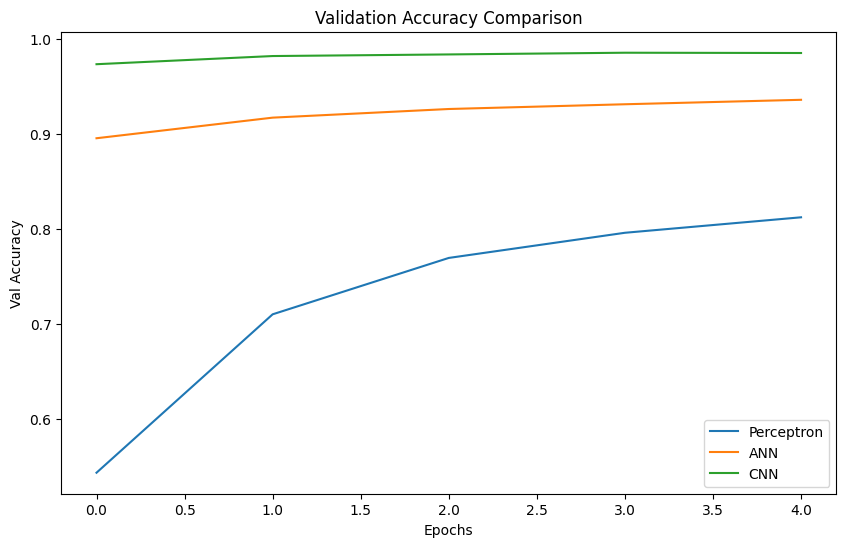

In [54]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [55]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


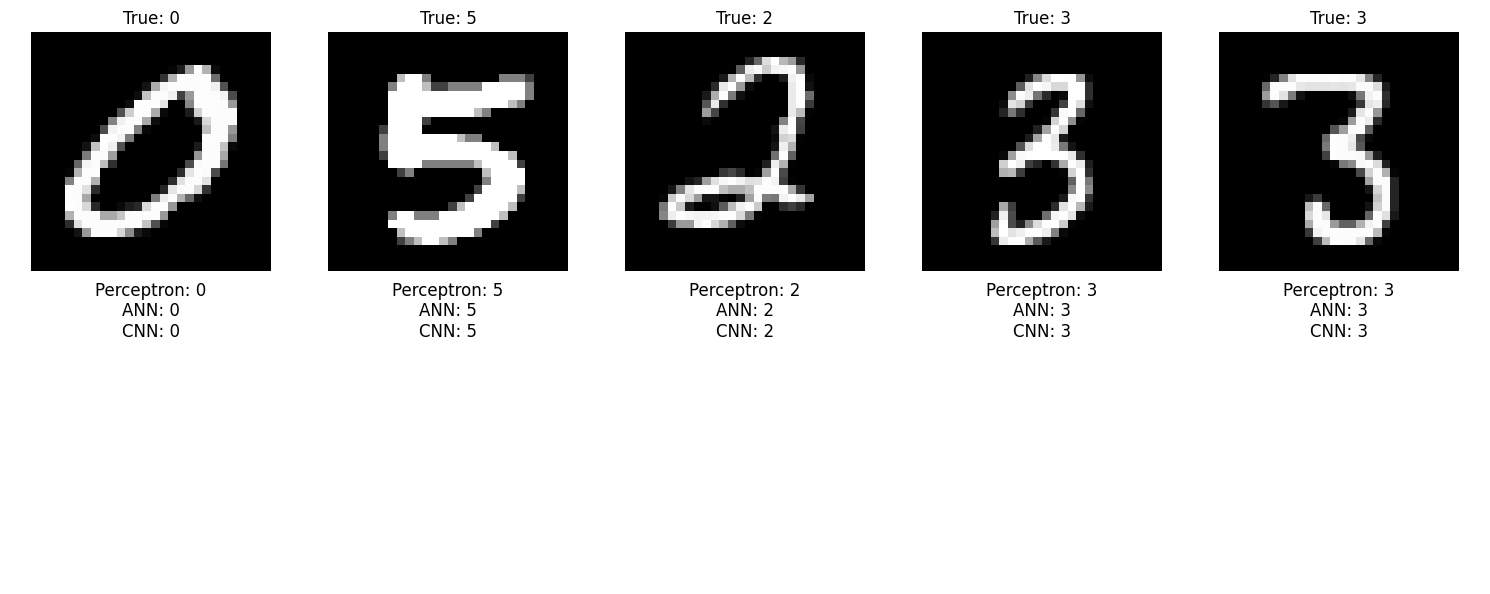

In [62]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


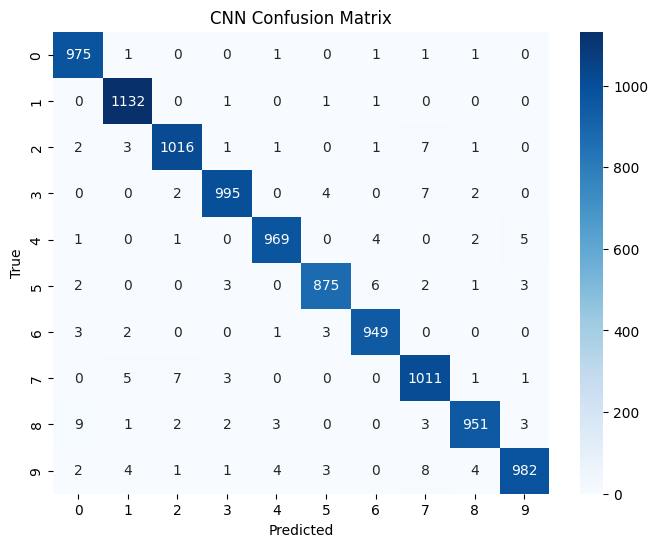

In [63]:

y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

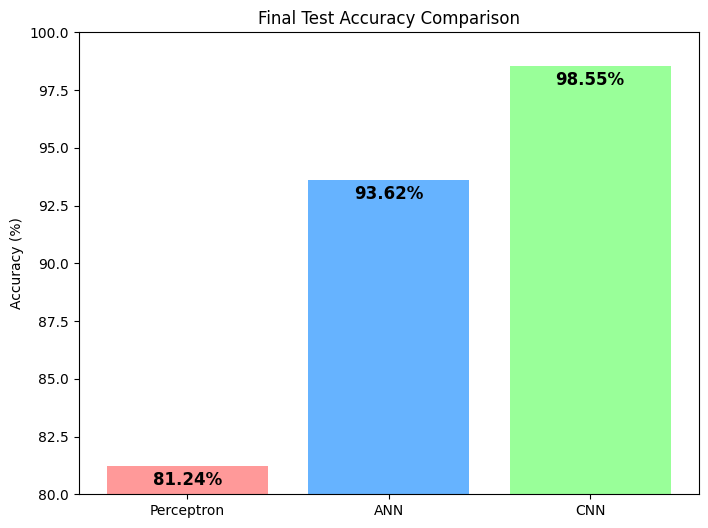

In [64]:


final_accs = [acc_percp*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()